In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load data
X = np.load('../data/X_balanced_features.npy')
y = np.load('../data/y_balanced_labels.npy')

# One-hot encode for 36 classes
y_encoded = to_categorical(y, num_classes=36)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Build Sequential model
# Input shape (21, 3). Two stacked LSTMs with 25% Dropout.
# Dense 128 ReLU for deep feature extraction. Dense 36 softmax.
model = Sequential([
    Input(shape=(21, 3)),
    LSTM(64, return_sequences=True),
    Dropout(0.25),
    LSTM(64),
    Dropout(0.25),
    Dense(128, activation='relu'),
    Dense(36, activation='softmax')
])

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train model with EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping]
)

# Save the trained model
model.save('../model/lstm_asl_model.keras')
print("Model saved to Drive as lstm_asl_model.keras")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,396 (247.64 KB)

 Trainable params: 63,396 (247.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.1952 - loss: 2.7296 - val_accuracy: 0.5569 - val_loss: 1.2973
Epoch 2/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.6174 - loss: 1.0709 - val_accuracy: 0.8411 - val_loss: 0.4616
Epoch 3/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8003 - loss: 0.5415 - val_accuracy: 0.9414 - val_loss: 0.1862
Epoch 4/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8901 - loss: 0.3141 - val_accuracy: 0.9669 - val_loss: 0.1117
Epoch 5/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9314 - loss: 0.1998 - val_accuracy: 0.9618 - val_loss: 0.1079
Epoch 6/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9420 - loss: 0.1735 - val_accuracy: 0.9832 - val_loss: 0.0535
Epoch 7/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9574 - loss: 0.1240 - val_accuracy: 0.9800 - val_loss: 0.0630
Epoch 8/100
900/900 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9644 - loss: 0.1103 - v

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       193
           1       1.00      1.00      1.00       208
           2       1.00      1.00      1.00       195
           3       1.00      1.00      1.00       207
           4       1.00      1.00      1.00       208
           5       1.00      1.00      1.00       209
           6       1.00      1.00      1.00       210
           7       1.00      1.00      1.00       207
           8       1.00      1.00      1.00       203
           9       1.00      1.00      1.00       191
           A       1.00      0.99      1.00       193
           B       1.00      1.00      1.00       176
           C       1.00      1.00      1.00       206
           D       1.00      1.00      1.00       207
           E       1.00      1.00      1.00       204
           F       1.00      1.00      1.00       191
           G     

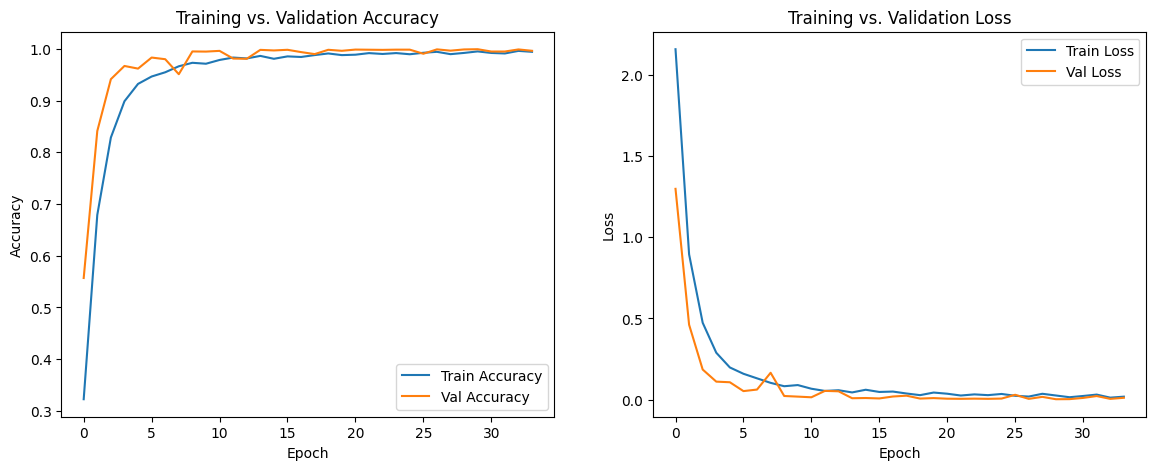

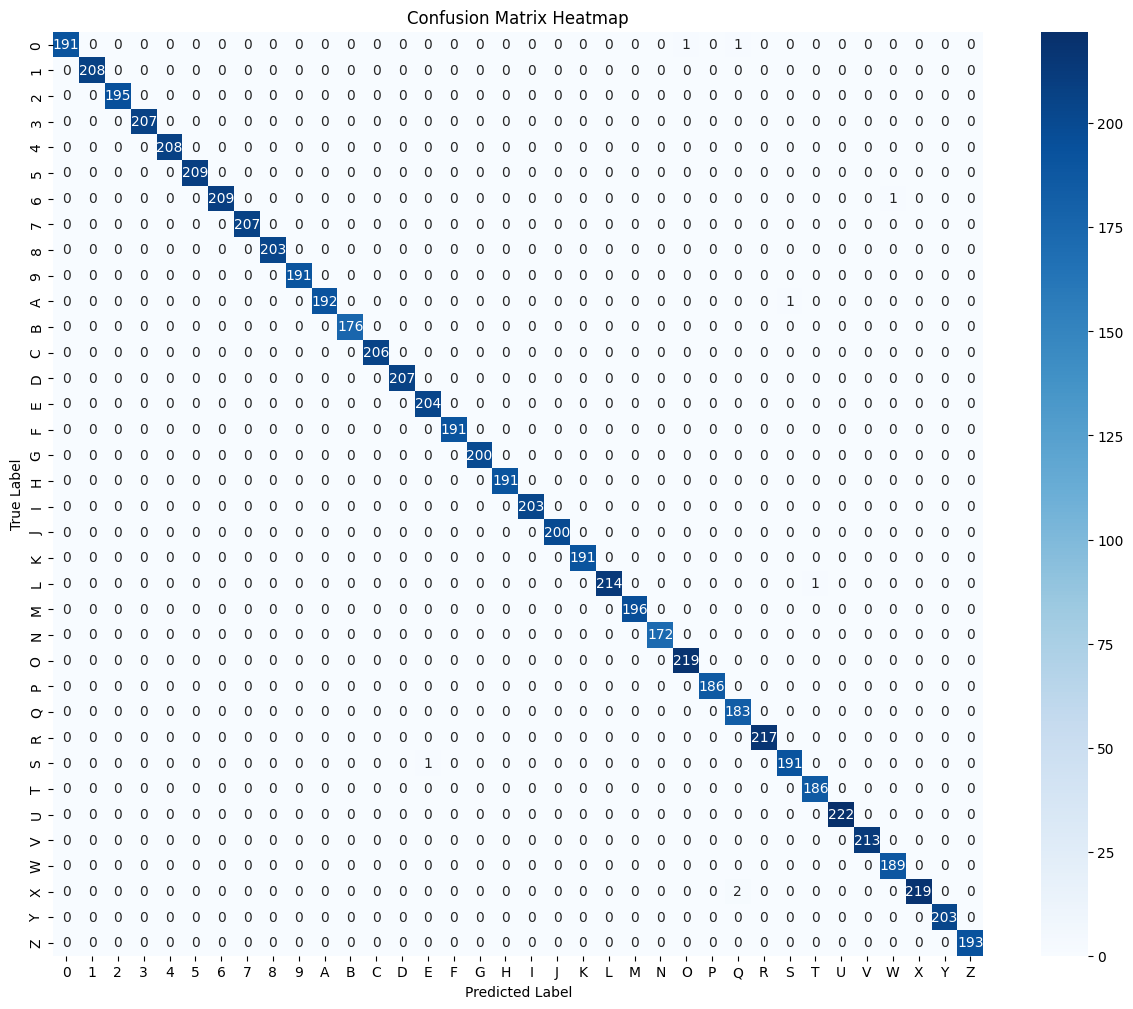

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load classes mapping to get the original string labels (A-Z, 0-9)
classes_mapping = np.load('../data/classes_mapping.npy', allow_pickle=True)


# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Full classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes_mapping))

# Plot accuracy and loss curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Training vs. Validation Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

# Loss
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Training vs. Validation Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

# Confusion Matrix Heatmap
plt.figure(figsize=(15, 12))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_mapping, yticklabels=classes_mapping)
plt.title('Confusion Matrix Heatmap')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
